Problem statement:Build a model to predict happiness based on the provided fields.

**EDA**

In [1]:
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LogisticRegression, LinearRegression
import xgboost as xgb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_2015=pd.read_csv("2015.csv")
df_2016=pd.read_csv("2016.csv")
df_2017=pd.read_csv("2017.csv")
df_2018=pd.read_csv("2018.csv")
df_2019=pd.read_csv("2019.csv")

In [3]:
print("2015 Columns:", df_2015.columns.tolist())
print("2016 Columns:", df_2016.columns.tolist())
print("2017 Columns:", df_2017.columns.tolist())
print("2018 Columns:", df_2018.columns.tolist())
print("2019 Columns:", df_2019.columns.tolist())

2015 Columns: ['Country', 'Region', 'Happiness Rank', 'Happiness Score', 'Standard Error', 'Economy (GDP per Capita)', 'Family', 'Health (Life Expectancy)', 'Freedom', 'Trust (Government Corruption)', 'Generosity', 'Dystopia Residual']
2016 Columns: ['Country', 'Region', 'Happiness Rank', 'Happiness Score', 'Lower Confidence Interval', 'Upper Confidence Interval', 'Economy (GDP per Capita)', 'Family', 'Health (Life Expectancy)', 'Freedom', 'Trust (Government Corruption)', 'Generosity', 'Dystopia Residual']
2017 Columns: ['Country', 'Happiness.Rank', 'Happiness.Score', 'Whisker.high', 'Whisker.low', 'Economy..GDP.per.Capita.', 'Family', 'Health..Life.Expectancy.', 'Freedom', 'Generosity', 'Trust..Government.Corruption.', 'Dystopia.Residual']
2018 Columns: ['Overall rank', 'Country or region', 'Score', 'GDP per capita', 'Social support', 'Healthy life expectancy', 'Freedom to make life choices', 'Generosity', 'Perceptions of corruption']
2019 Columns: ['Overall rank', 'Country or region'

In [4]:

# comprehensive mapping dictionary
column_mapping = {
    # Country/Region names
    'Country': 'country',
    'Country or region': 'country',
    'Region': 'region',

    # Rank/Score names
    'Happiness Rank': 'rank',
    'Happiness.Rank': 'rank',
    'Overall rank': 'rank',
    'Happiness Score': 'score',
    'Happiness.Score': 'score',
    'Score': 'score',

    # Factor names
    'Economy (GDP per Capita)': 'gdp_per_capita',
    'Economy..GDP.per.Capita.': 'gdp_per_capita',
    'GDP per capita': 'gdp_per_capita',

    'Family': 'social_support',
    'Social support': 'social_support',

    'Health (Life Expectancy)': 'healthy_life_expectancy',
    'Health..Life.Expectancy.': 'healthy_life_expectancy',
    'Healthy life expectancy': 'healthy_life_expectancy',

    'Freedom': 'freedom',
    'Freedom to make life choices': 'freedom',

    'Trust (Government Corruption)': 'perceptions_of_corruption',
    'Trust..Government.Corruption.': 'perceptions_of_corruption',
    'Perceptions of corruption': 'perceptions_of_corruption',

    'Generosity': 'generosity',

    'Dystopia Residual': 'dystopia_residual',
    'Dystopia.Residual': 'dystopia_residual'
}

# List of columns we want in our final dataset
desired_columns = ['country', 'region', 'year', 'rank', 'score', 'gdp_per_capita',
                   'social_support', 'healthy_life_expectancy', 'freedom',
                   'perceptions_of_corruption', 'generosity', 'dystopia_residual']

def clean_dataframe(df, year):
    """Clean and standardize a single year's dataframe"""
    # copy to avoid modifying the original
    df_clean = df.copy()

    # Rename columns using the mapping (only for columns that exist)
    df_clean = df_clean.rename(columns={k: v for k, v in column_mapping.items()
                                       if k in df_clean.columns})

    # Adding year column
    df_clean['year'] = year

    # Ensuring all desired columns exist (add missing ones as NaN)
    for col in desired_columns:
        if col not in df_clean.columns:
            df_clean[col] = np.nan

    # Returning only the desired columns in consistent order
    return df_clean[desired_columns]

#  cleaning each dataframe
dfs_clean = []
for year, df in zip([2015, 2016, 2017, 2018, 2019],
                    [df_2015, df_2016, df_2017, df_2018, df_2019]):
    dfs_clean.append(clean_dataframe(df, year))

# Concatenating all dataframes
df_combined = pd.concat(dfs_clean, ignore_index=True)

# Handling region mapping (since region is only in 2015-2016)
region_map = df_combined[df_combined['region'].notna()][['country', 'region']].drop_duplicates()
df_combined = df_combined.drop('region', axis=1)  # Removes the incomplete region column
df_combined = pd.merge(df_combined, region_map, on='country', how='left')

print("Combined DataFrame shape:", df_combined.shape)
print(df_combined.head())

Combined DataFrame shape: (782, 12)
       country  year  rank  score  gdp_per_capita  social_support  \
0  Switzerland  2015     1  7.587         1.39651         1.34951   
1      Iceland  2015     2  7.561         1.30232         1.40223   
2      Denmark  2015     3  7.527         1.32548         1.36058   
3       Norway  2015     4  7.522         1.45900         1.33095   
4       Canada  2015     5  7.427         1.32629         1.32261   

   healthy_life_expectancy  freedom  perceptions_of_corruption  generosity  \
0                  0.94143  0.66557                    0.41978     0.29678   
1                  0.94784  0.62877                    0.14145     0.43630   
2                  0.87464  0.64938                    0.48357     0.34139   
3                  0.88521  0.66973                    0.36503     0.34699   
4                  0.90563  0.63297                    0.32957     0.45811   

   dystopia_residual          region  
0            2.51738  Western Europe  
1 

In [5]:
# Gets statistical summary for numerical columns
numerical_columns = ['score', 'gdp_per_capita', 'social_support',
                     'healthy_life_expectancy', 'freedom',
                     'perceptions_of_corruption', 'generosity']

print("Statistical Summary:")
print(df_combined[numerical_columns].describe())


Statistical Summary:
            score  gdp_per_capita  social_support  healthy_life_expectancy  \
count  782.000000      782.000000      782.000000               782.000000   
mean     5.379018        0.916047        1.078392                 0.612416   
std      1.127456        0.407340        0.329548                 0.248309   
min      2.693000        0.000000        0.000000                 0.000000   
25%      4.509750        0.606500        0.869363                 0.440183   
50%      5.322000        0.982205        1.124735                 0.647310   
75%      6.189500        1.236187        1.327250                 0.808000   
max      7.769000        2.096000        1.644000                 1.141000   

          freedom  perceptions_of_corruption  generosity  
count  782.000000                 781.000000  782.000000  
mean     0.411091                   0.125436    0.218576  
std      0.152880                   0.105816    0.122321  
min      0.000000                   0.00

In [6]:
df_combined.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 782 entries, 0 to 781
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   country                    782 non-null    object 
 1   year                       782 non-null    int64  
 2   rank                       782 non-null    int64  
 3   score                      782 non-null    float64
 4   gdp_per_capita             782 non-null    float64
 5   social_support             782 non-null    float64
 6   healthy_life_expectancy    782 non-null    float64
 7   freedom                    782 non-null    float64
 8   perceptions_of_corruption  781 non-null    float64
 9   generosity                 782 non-null    float64
 10  dystopia_residual          470 non-null    float64
 11  region                     774 non-null    object 
dtypes: float64(8), int64(2), object(2)
memory usage: 73.4+ KB


In [7]:
df_combined.dropna(inplace=True)

In [8]:
df_combined.duplicated().sum()

np.int64(0)

In [9]:
print("Variance of Numerical Columns:")  #checking for variance as we need features that have a relative spread variance in order to prevent overfitting
print(df_combined[numerical_columns].var())

Variance of Numerical Columns:
score                        1.295907
gdp_per_capita               0.172063
social_support               0.101515
healthy_life_expectancy      0.057542
freedom                      0.022683
perceptions_of_corruption    0.012379
generosity                   0.017340
dtype: float64


In [10]:
df_combined.drop(['country','year','rank','dystopia_residual','region'], inplace=True, axis=1) #dropped these coulmns because they are not relevant to the model
df_combined.columns

Index(['score', 'gdp_per_capita', 'social_support', 'healthy_life_expectancy',
       'freedom', 'perceptions_of_corruption', 'generosity'],
      dtype='object')

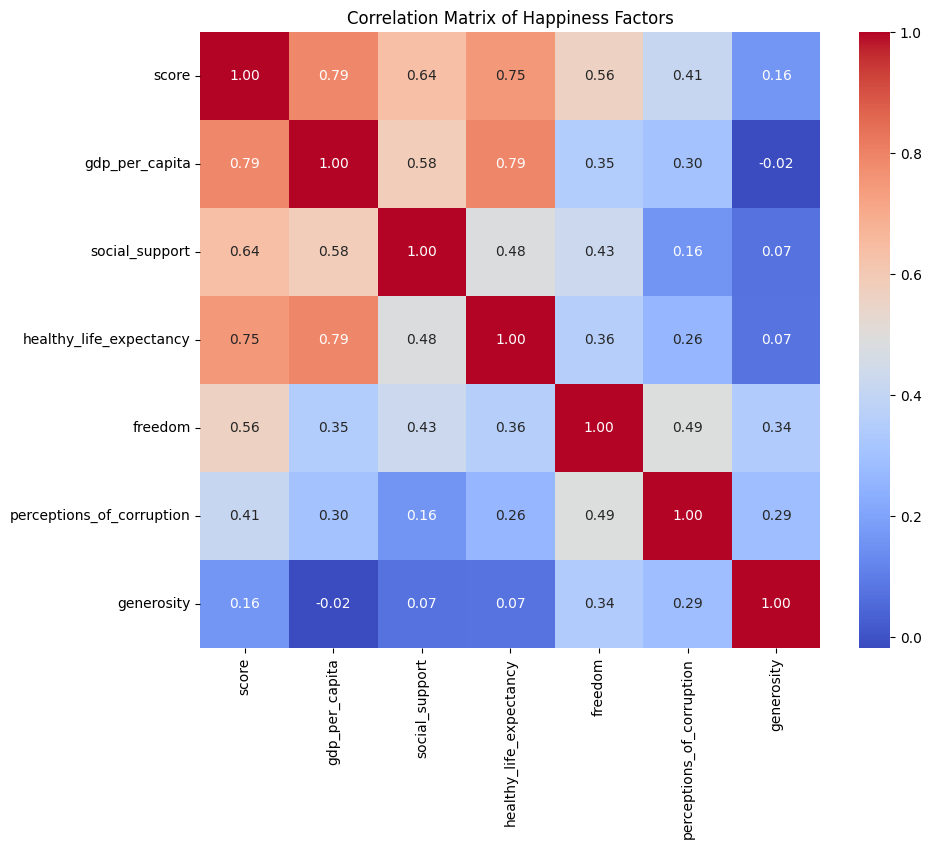

In [11]:
# Finding correlation bewtween fields
correlation_matrix = df_combined.corr()

# Plot the correlation matrix as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Happiness Factors')
plt.show()

**NB**;The most correlated features with happiness are gdp_per_capita,social_support,healty_life_expectancy.Most of the features have moderate correlation between each other but notably there is a very high correlation between gdp_per_capita and healthy_life_epectancy that could cause **multicollinearity**

DATA **PROCESSING**

In [12]:
# Define features (X) and target (y)
X = df_combined.drop('score', axis=1)
y = df_combined['score']

# Split data into training (60%) and temporary (40%) sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)

# Split temporary set into validation (20%) and test (20%) sets
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42) # 0.5 of 0.4 is 0.2

# Initialize the scaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform all sets
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Shape of X_train_scaled:", X_train_scaled.shape)
print("Shape of X_val_scaled:", X_val_scaled.shape)
print("Shape of X_test_scaled:", X_test_scaled.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_val:", y_val.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train_scaled: (280, 6)
Shape of X_val_scaled: (94, 6)
Shape of X_test_scaled: (94, 6)
Shape of y_train: (280,)
Shape of y_val: (94,)
Shape of y_test: (94,)


**MODEL TRAINING AND EVALUATION**

We use a linear regression model as it is simple and will help us understand the linear relationship between the features and happiness.

**Advantages**

1.Simple

2.Helps us understand the relationship between the features and traget variables.

**Weaknesses**
1.Assumes linearity(may not perform well if relationship is non-linear)

2.Sensitive to outliers

3.Normality

4.No multicollinearity



In [13]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error

# Build and train a Linear Regression model
linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_train)

# Evaluate the Linear Regression model on the validation set
y_val_pred_linear = linear_model.predict(X_val_scaled)

# Calculate evaluation metrics
mae_linear = mean_absolute_error(y_val, y_val_pred_linear)
mse_linear = mean_squared_error(y_val, y_val_pred_linear)
rmse_linear = mse_linear**0.5
r2_linear = r2_score(y_val, y_val_pred_linear)
mape_linear = mean_absolute_percentage_error(y_val, y_val_pred_linear)


print("Linear Regression Metrics on validation set:")
print(f"  MAE: {mae_linear:.4f}")
print(f"  MSE: {mse_linear:.4f}")
print(f"  RMSE: {rmse_linear:.4f}")
print(f"  R-squared: {r2_linear:.4f}")
print(f"  MAPE: {mape_linear:.4f}")

Linear Regression Metrics on validation set:
  MAE: 0.4208
  MSE: 0.3091
  RMSE: 0.5559
  R-squared: 0.7805
  MAPE: 0.0898


We use the RandomForestRegressor as an ensemble method that can capture non-linear relationships between features and it is more robust to outliers.

**Strengths**

1.Can handle non-linear relationships

2.Less sensitive to outliers.

**Weaknesses**

1.More complex which can lead to overfitting

**Assumptions**

1.Independence of data

2.Identical distribution of data

In [14]:

# Build and train a Random Forest Regressor model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

# Evaluate the Random Forest Regressor model on the validation set
y_val_pred_rf = rf_model.predict(X_val_scaled)

# Calculate evaluation metrics
mae_rf = mean_absolute_error(y_val, y_val_pred_rf)
mse_rf = mean_squared_error(y_val, y_val_pred_rf)
rmse_rf = mse_rf**0.5
r2_rf = r2_score(y_val, y_val_pred_rf)
mape_rf = mean_absolute_percentage_error(y_val, y_val_pred_rf)


print("Random Forest Regressor Metrics on validation set:")
print(f"  MAE: {mae_rf:.4f}")
print(f"  MSE: {mse_rf:.4f}")
print(f"  RMSE: {rmse_rf:.4f}")
print(f"  R-squared: {r2_rf:.4f}")
print(f"  MAPE: {mape_rf:.4f}")

Random Forest Regressor Metrics on validation set:
  MAE: 0.4054
  MSE: 0.2515
  RMSE: 0.5015
  R-squared: 0.8213
  MAPE: 0.0858


We use XBoost for more robust gradient boosting ie more speed and performance

**Strengths**

1.Higher accuracy and performance

2.Regularization techniques to prevent overfitting

3.Can handle non-linear relationships

**Weaknesses**

1.More complex

**Assumptions**

1.Independence of data

2.Identical distribution

In [15]:

# Build and train an XGBoost Regressor model
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, random_state=42)
xgb_model.fit(X_train_scaled, y_train)

# Evaluate the XGBoost Regressor model on the validation set
y_val_pred_xgb = xgb_model.predict(X_val_scaled)

# Calculate evaluation metrics
mae_xgb = mean_absolute_error(y_val, y_val_pred_xgb)
mse_xgb = mean_squared_error(y_val, y_val_pred_xgb)
rmse_xgb = mse_xgb**0.5
r2_xgb = r2_score(y_val, y_val_pred_xgb)
mape_xgb = mean_absolute_percentage_error(y_val, y_val_pred_xgb)

print("XGBoost Regressor Metrics on validation set:")
print(f"  MAE: {mae_xgb:.4f}")
print(f"  MSE: {mse_xgb:.4f}")
print(f"  RMSE: {rmse_xgb:.4f}")
print(f"  R-squared: {r2_xgb:.4f}")
print(f"  MAPE: {mape_xgb:.4f}")

XGBoost Regressor Metrics on validation set:
  MAE: 0.3954
  MSE: 0.2419
  RMSE: 0.4919
  R-squared: 0.8281
  MAPE: 0.0827


**Check for overfitting and underfitting**

In [16]:
# Evaluate Linear Regression on training set
y_train_pred_linear = linear_model.predict(X_train_scaled)
mae_train_linear = mean_absolute_error(y_train, y_train_pred_linear)
mse_train_linear = mean_squared_error(y_train, y_train_pred_linear)
rmse_train_linear = mse_train_linear**0.5
r2_train_linear = r2_score(y_train, y_train_pred_linear)
mape_train_linear = mean_absolute_percentage_error(y_train, y_train_pred_linear)

print("Linear Regression Metrics on training set:")
print(f"  MAE: {mae_train_linear:.4f}")
print(f"  MSE: {mse_train_linear:.4f}")
print(f"  RMSE: {rmse_train_linear:.4f}")
print(f"  R-squared: {r2_train_linear:.4f}")
print(f"  MAPE: {mape_train_linear:.4f}")

print("Linear Regression Overfitting Check (Train vs Val):")
print(f"  MAE Difference (Train - Val): {mae_train_linear - mae_linear:.4f}")
print(f"  MSE Difference (Train - Val): {mse_train_linear - mse_linear:.4f}")
print(f"  RMSE Difference (Train - Val): {rmse_train_linear - rmse_linear:.4f}")
print(f"  R-squared Difference (Train - Val): {r2_train_linear - r2_linear:.4f}")
print(f"  MAPE Difference (Train - Val): {mape_train_linear - mape_linear:.4f}")

# Evaluate Random Forest on training set
y_train_pred_rf = rf_model.predict(X_train_scaled)
mae_train_rf = mean_absolute_error(y_train, y_train_pred_rf)
mse_train_rf = mean_squared_error(y_train, y_train_pred_rf)
rmse_train_rf = mse_train_rf**0.5
r2_train_rf = r2_score(y_train, y_train_pred_rf)
mape_train_rf = mean_absolute_percentage_error(y_train, y_train_pred_rf)

print("Random Forest Regressor Metrics on training set:")
print(f"  MAE: {mae_train_rf:.4f}")
print(f"  MSE: {mse_train_rf:.4f}")
print(f"  RMSE: {rmse_train_rf:.4f}")
print(f"  R-squared: {r2_train_rf:.4f}")
print(f"  MAPE: {mape_train_rf:.4f}")

print("Random Forest Regressor Overfitting Check (Train vs Val):")
print(f"  MAE Difference (Train - Val): {mae_train_rf - mae_rf:.4f}")
print(f"  MSE Difference (Train - Val): {mse_train_rf - mse_rf:.4f}")
print(f"  RMSE Difference (Train - Val): {rmse_train_rf - rmse_rf:.4f}")
print(f"  R-squared Difference (Train - Val): {r2_train_rf - r2_rf:.4f}")
print(f"  MAPE Difference (Train - Val): {mape_train_rf - mape_rf:.4f}")

# Evaluate initial XGBoost on training set
y_train_pred_xgb = xgb_model.predict(X_train_scaled)
mae_train_xgb = mean_absolute_error(y_train, y_train_pred_xgb)
mse_train_xgb = mean_squared_error(y_train, y_train_pred_xgb)
rmse_train_xgb = mse_train_xgb**0.5
r2_train_xgb = r2_score(y_train, y_train_pred_xgb)
mape_train_xgb = mean_absolute_percentage_error(y_train, y_train_pred_xgb)

print("Initial XGBoost Regressor Metrics on training set:")
print(f"  MAE: {mae_train_xgb:.4f}")
print(f"  MSE: {mse_train_xgb:.4f}")
print(f"  RMSE: {rmse_train_xgb:.4f}")
print(f"  R-squared: {r2_train_xgb:.4f}")
print(f"  MAPE: {mape_train_xgb:.4f}")

print("Initial XGBoost Regressor Overfitting Check (Train vs Val):")
print(f"  MAE Difference (Train - Val): {mae_train_xgb - mae_xgb:.4f}")
print(f"  MSE Difference (Train - Val): {mse_train_xgb - mse_xgb:.4f}")
print(f"  RMSE Difference (Train - Val): {rmse_train_xgb - rmse_xgb:.4f}")
print(f"  R-squared Difference (Train - Val): {r2_train_xgb - r2_xgb:.4f}")
print(f"  MAPE Difference (Train - Val): {mape_train_xgb - mape_xgb:.4f}")

Linear Regression Metrics on training set:
  MAE: 0.4394
  MSE: 0.3110
  RMSE: 0.5577
  R-squared: 0.7569
  MAPE: 0.0856
Linear Regression Overfitting Check (Train vs Val):
  MAE Difference (Train - Val): 0.0186
  MSE Difference (Train - Val): 0.0020
  RMSE Difference (Train - Val): 0.0018
  R-squared Difference (Train - Val): -0.0235
  MAPE Difference (Train - Val): -0.0042
Random Forest Regressor Metrics on training set:
  MAE: 0.1634
  MSE: 0.0435
  RMSE: 0.2086
  R-squared: 0.9660
  MAPE: 0.0326
Random Forest Regressor Overfitting Check (Train vs Val):
  MAE Difference (Train - Val): -0.2421
  MSE Difference (Train - Val): -0.2080
  RMSE Difference (Train - Val): -0.2929
  R-squared Difference (Train - Val): 0.1447
  MAPE Difference (Train - Val): -0.0533
Initial XGBoost Regressor Metrics on training set:
  MAE: 0.0008
  MSE: 0.0000
  RMSE: 0.0012
  R-squared: 1.0000
  MAPE: 0.0002
Initial XGBoost Regressor Overfitting Check (Train vs Val):
  MAE Difference (Train - Val): -0.3946
 

**Linear Regression:**

Training Metrics: MAE: 0.4394, MSE: 0.3110, RMSE: 0.5577, R-squared: 0.7569, MAPE: 0.0856

Validation Metrics: MAE: 0.4208, MSE: 0.3091, RMSE: 0.5559, R-squared: 0.7805, MAPE: 0.0898

Differences (Train - Val): MAE: 0.0186, MSE: 0.0020, RMSE: 0.0018, R-squared: -0.0235, MAPE: -0.0042

**Interpretation:**

The differences between the training and validation metrics are very small. This indicates that the Linear Regression model performs very similarly on both the training and validation sets. This suggests that Linear Regression is not overfitting the training data.


**Random Forest Regressor:**

Training Metrics: MAE: 0.1634, MSE: 0.0435, RMSE: 0.2086, R-squared: 0.9660, MAPE: 0.0326

Validation Metrics: MAE: 0.4054, MSE: 0.2515, RMSE: 0.5015, R-squared: 0.8213, MAPE: 0.0858
Differences (Train - Val): MAE: -0.2421, MSE: -0.2080,

RMSE: -0.2929, R-squared: 0.1447, MAPE: -0.0533

**Interpretation: **

There's a notable difference between the training and validation metrics. The error metrics (MAE, MSE, RMSE, MAPE) are significantly lower on the training set, and the R-squared is much higher. This indicates that the Random Forest model is performing much better on the data it was trained on compared to the unseen validation data. This suggests that Random Forest is overfitting the training data to some extent.

**Initial XGBoost Regressor:**

Training Metrics: MAE: 0.0008, MSE: 0.0000, RMSE: 0.0012, R-squared: 1.0000, MAPE: 0.0002

Validation Metrics: MAE: 0.3954, MSE: 0.2419, RMSE: 0.4919, R-squared: 0.8281, MAPE: 0.0827
Differences (Train - Val): MAE: -0.3946, MSE: -0.2419,
RMSE: -0.4907, R-squared: 0.1719, MAPE: -0.0825

**Interpretation:**

The difference between the training and validation metrics is very large. The error metrics on the training set are extremely low (almost zero), and the R-squared is nearly perfect (1.0). This indicates that the initial XGBoost model has learned the training data almost perfectly but does not generalize well to the validation data. This suggests that the initial XGBoost is significantly overfitting the training data.

**Hyperparameter Tuning for XGBoost Regressor**

In [17]:
# Hyperparameter tuning for XGBoost Regressor
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 4, 5],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0]
}

xgb_grid_search = GridSearchCV(estimator=xgb.XGBRegressor(objective='reg:squarederror', random_state=42),
                               param_grid=param_grid,
                               cv=5,
                               scoring='neg_mean_squared_error',
                               n_jobs=-1)

xgb_grid_search.fit(X_train_scaled, y_train)

print("Best parameters for XGBoost:", xgb_grid_search.best_params_)
print("Best RMSE during cross-validation:", (-xgb_grid_search.best_score_)**0.5)

Best parameters for XGBoost: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 300, 'subsample': 0.8}
Best RMSE during cross-validation: 0.573356470343666


**Evaluate the best XGBoost model on the validation set**

In [18]:
best_xgb_model = xgb_grid_search.best_estimator_
y_val_pred_best_xgb = best_xgb_model.predict(X_val_scaled)

# Calculate evaluation metrics for the best XGBoost model on the validation set
mae_val_best_xgb = mean_absolute_error(y_val, y_val_pred_best_xgb)
mse_val_best_xgb = mean_squared_error(y_val, y_val_pred_best_xgb)
rmse_val_best_xgb = mse_val_best_xgb**0.5
r2_val_best_xgb = r2_score(y_val, y_val_pred_best_xgb)
mape_val_best_xgb = mean_absolute_percentage_error(y_val, y_val_pred_best_xgb)

print("Best XGBoost Regressor Metrics on validation set after tuning:")
print(f"  MAE: {mae_val_best_xgb:.4f}")
print(f"  MSE: {mse_val_best_xgb:.4f}")
print(f"  RMSE: {rmse_val_best_xgb:.4f}")
print(f"  R-squared: {r2_val_best_xgb:.4f}")
print(f"  MAPE: {mape_val_best_xgb:.4f}")

Best XGBoost Regressor Metrics on validation set after tuning:
  MAE: 0.3740
  MSE: 0.2271
  RMSE: 0.4766
  R-squared: 0.8387
  MAPE: 0.0806


**Model** **comparison**

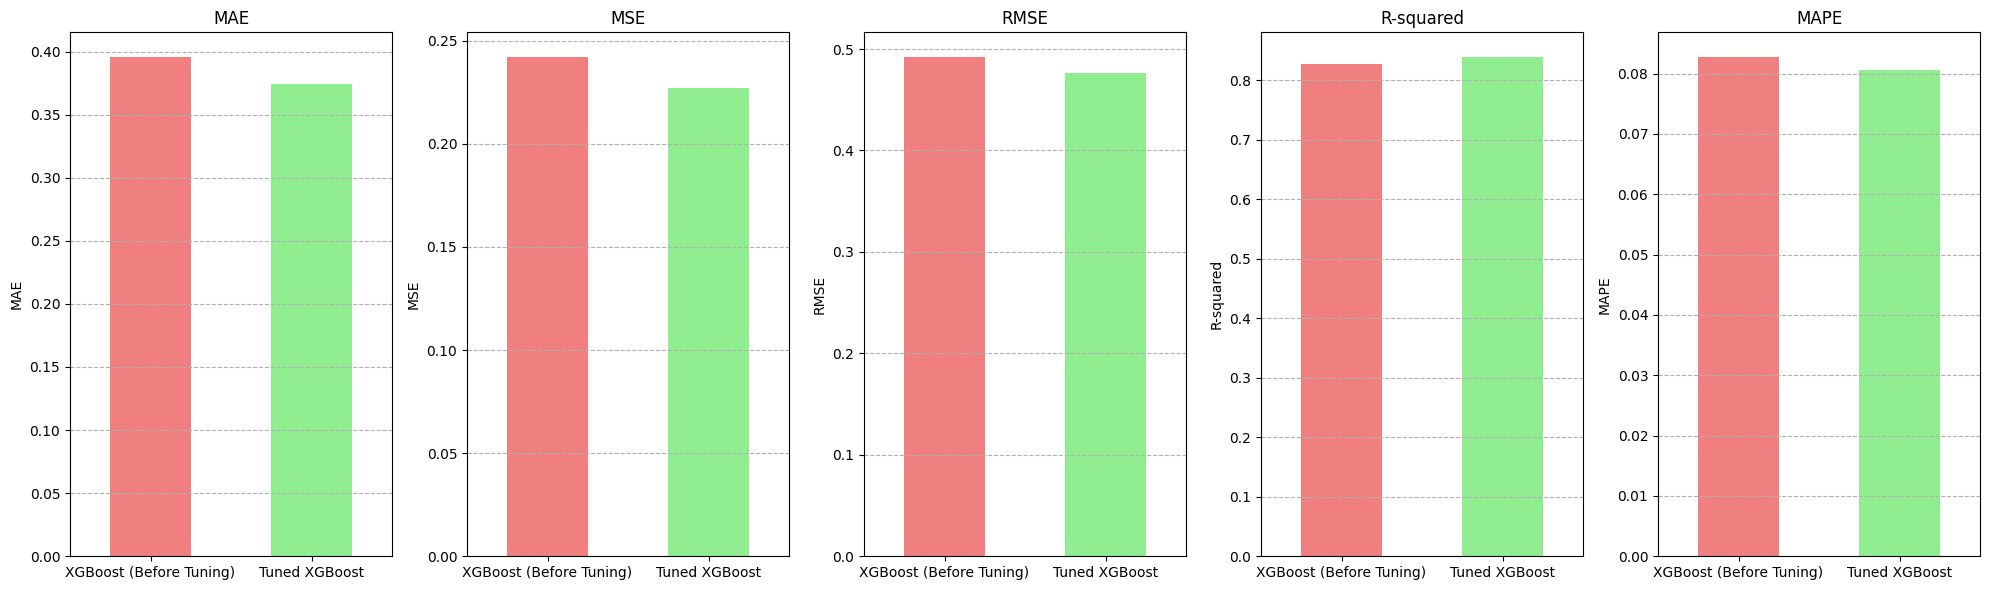

In [19]:
# Create a dictionary for XGBoost metrics before and after tuning
xgb_tuning_comparison = {
    'XGBoost (Before Tuning)': {'MAE': mae_xgb, 'MSE': mse_xgb, 'RMSE': rmse_xgb, 'R-squared': r2_xgb, 'MAPE': mape_xgb},
    'Tuned XGBoost': {'MAE': mae_val_best_xgb, 'MSE': mse_val_best_xgb, 'RMSE': rmse_val_best_xgb, 'R-squared': r2_val_best_xgb, 'MAPE': mape_val_best_xgb}
}

# Convert the dictionary to a pandas DataFrame
xgb_tuning_df = pd.DataFrame.from_dict(xgb_tuning_comparison, orient='index')

# Plotting the comparison
fig, axes = plt.subplots(nrows=1, ncols=5, figsize=(20, 6))
axes = axes.flatten()

metrics_to_plot = ['MAE', 'MSE', 'RMSE', 'R-squared', 'MAPE']
colors = ['lightcoral', 'lightgreen']

for i, metric in enumerate(metrics_to_plot):
    xgb_tuning_df[metric].plot(kind='bar', ax=axes[i], color=colors)
    axes[i].set_title(metric)
    axes[i].set_ylabel(metric)
    axes[i].tick_params(axis='x', rotation=0)
    axes[i].grid(axis='y', linestyle='--')

plt.tight_layout()
plt.show()

In [20]:
# Evaluate the best XGBoost model on the test set
y_test_pred_best_xgb = best_xgb_model.predict(X_test_scaled)

# Calculate evaluation metrics for the best XGBoost model on the test set
mae_test_best_xgb = mean_absolute_error(y_test, y_test_pred_best_xgb)
mse_test_best_xgb = mean_squared_error(y_test, y_test_pred_best_xgb)
rmse_test_best_xgb = mse_test_best_xgb**0.5
r2_test_best_xgb = r2_score(y_test, y_test_pred_best_xgb)
mape_test_best_xgb = mean_absolute_percentage_error(y_test, y_test_pred_best_xgb)

print("Tuned XGBoost Regressor Metrics on test set:")
print(f"  MAE: {mae_test_best_xgb:.4f}")
print(f"  MSE: {mse_test_best_xgb:.4f}")
print(f"  RMSE: {rmse_test_best_xgb:.4f}")
print(f"  R-squared: {r2_test_best_xgb:.4f}")
print(f"  MAPE: {mape_test_best_xgb:.4f}")

Tuned XGBoost Regressor Metrics on test set:
  MAE: 0.4050
  MSE: 0.2736
  RMSE: 0.5231
  R-squared: 0.7677
  MAPE: 0.0780


Feature Importances from Tuned XGBoost Model:
                     feature  importance
0             gdp_per_capita    0.354104
2    healthy_life_expectancy    0.281423
3                    freedom    0.142216
1             social_support    0.095071
4  perceptions_of_corruption    0.076956
5                 generosity    0.050230


/tmp/ipython-input-4090032553.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feature_importance_df, palette='viridis')


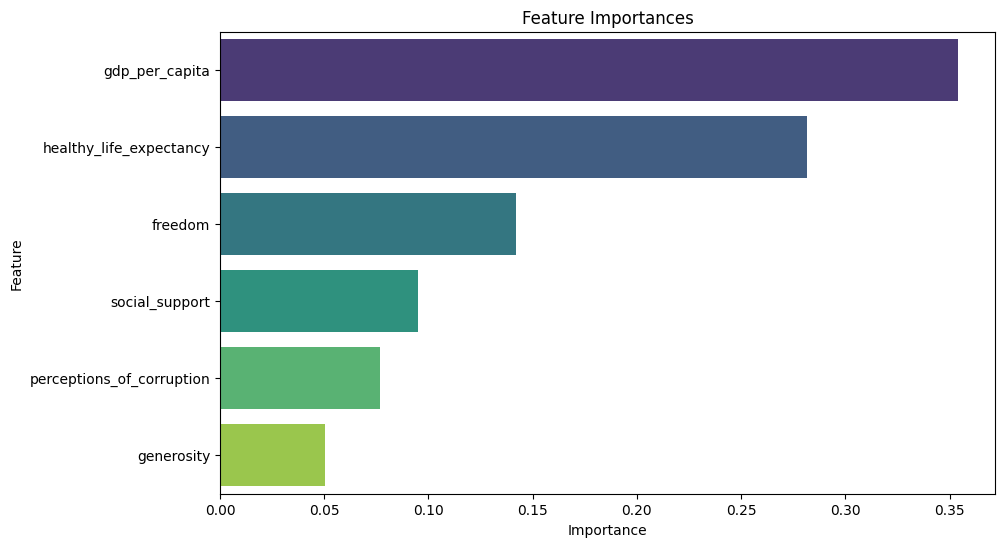

In [21]:
# Get feature importances from the best XGBoost model
feature_importances = best_xgb_model.feature_importances_

# Create a DataFrame to display feature importances
feature_importance_df = pd.DataFrame({'feature': X_train.columns, 'importance': feature_importances})

# Sort features by importance in descending order
feature_importance_df = feature_importance_df.sort_values('importance', ascending=False)

print("Feature Importances from Tuned XGBoost Model:")
print(feature_importance_df)

# Optional: Visualize feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=feature_importance_df, palette='viridis')
plt.title('Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()


**Analysis of  feature importances using SHAP, including summary plots, dependence plots, and force plots**

In [22]:
!pip install shap

In [23]:
import shap

# SHAP TreeExplainer for the tuned XGBoost model
explainer = shap.TreeExplainer(best_xgb_model)

In [24]:
# Calculate SHAP values
shap_values = explainer.shap_values(X_train_scaled)

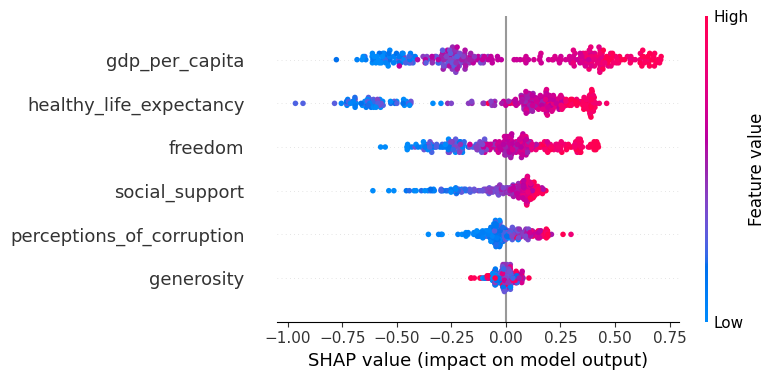

In [25]:
# SHAP summary plot
shap.summary_plot(shap_values, features=X_train_scaled, feature_names=X_train.columns)



Generate SHAP dependence plots for each feature to visualize the relationship between feature values and their SHAP values.



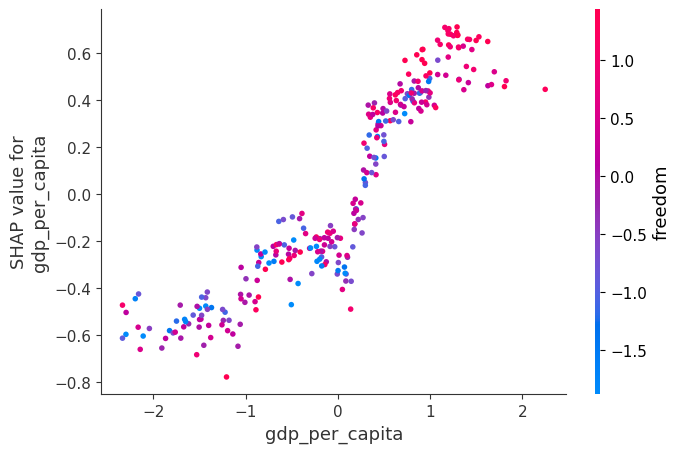

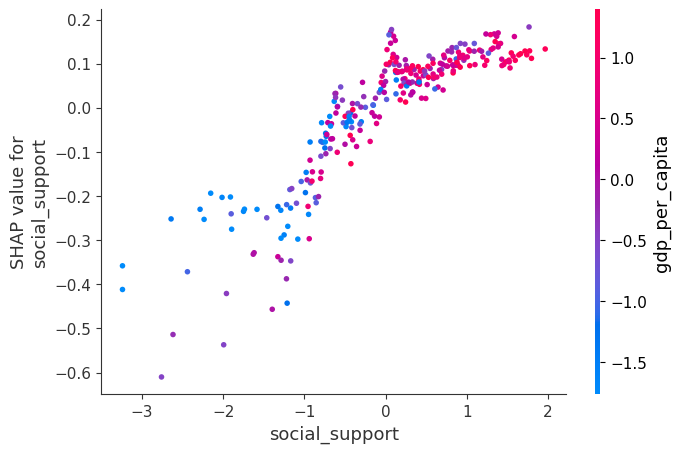

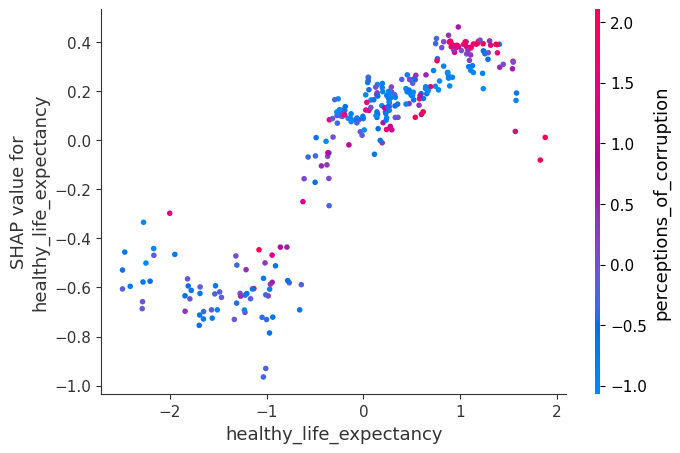

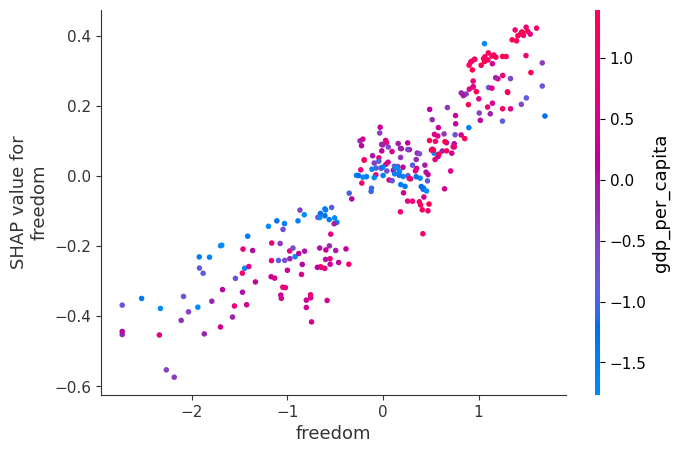

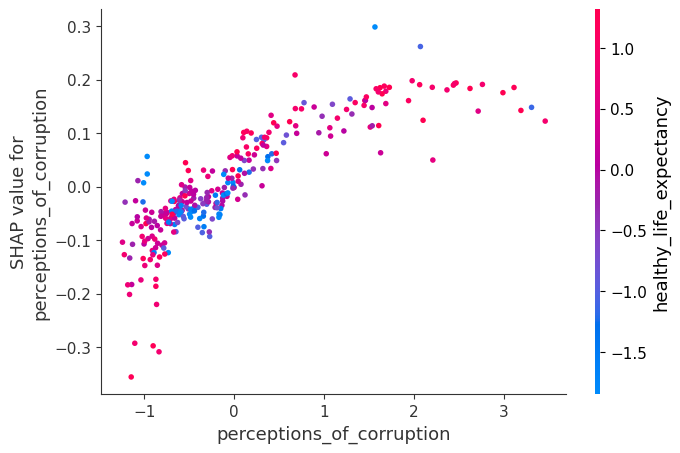

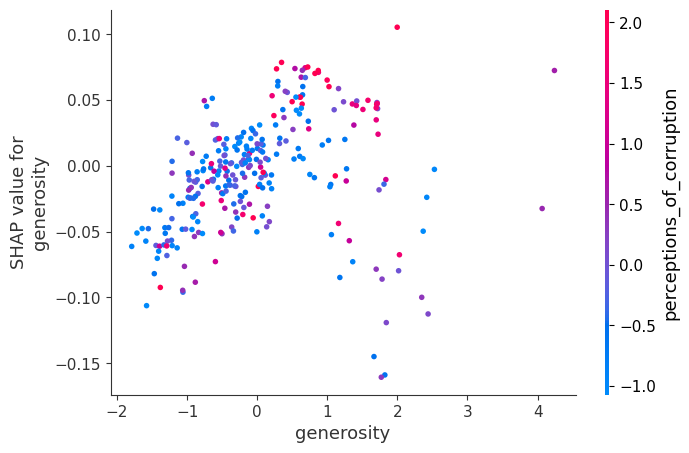

In [26]:
# Generate SHAP dependence plots for each feature
for feature_name in X_train.columns:
    shap.dependence_plot(feature_name, shap_values, features=X_train_scaled, feature_names=X_train.columns)

## Generate shap force plot (individual prediction)

### Subtask:
Visualize the contribution of each feature to a single prediction.


**Reasoning**:
Select a single instance and generate a SHAP force plot to visualize the contribution of each feature to that specific prediction.



In [27]:
# Select an index for a single instance (e.g., the first instance)
instance_index = 0

# Generate a SHAP force plot for the selected instance
shap.initjs() # Initialize JS visualization for the plot
shap.force_plot(explainer.expected_value, shap_values[instance_index], features=X_train_scaled[instance_index], feature_names=X_train.columns)

## Final Summary of Happiness Prediction Analysis

This notebook aimed to build a model to predict happiness scores based on various socio-economic and personal factors using the World Happiness Report data from 2015 to 2019.

**Data Preparation and Exploration:**

*   The analysis began by loading and combining happiness data from 2015 to 2019, addressing inconsistencies in column names across different years.
*   Missing values were handled by dropping rows with any missing data, and duplicate entries were checked and confirmed to be absent.
*    (EDA) included examining statistical summaries and visualizing the correlation matrix of numerical features. Key findings from EDA were:
    *   gdp_per_capita, social_support, and healthy_life_expectancy showed the strongest positive correlations with the happiness score.
    *   A notable high correlation was observed between gdp_per_capita and healthy_life_expectancy, suggesting potential multicollinearity.
*   Irrelevant columns (country, year, rank, dystopia_residual, region) were dropped for model training.
*   The data was split into training, validation, and test sets (60/20/20 split), and numerical features were scaled using StandardScaler to ensure they were on a similar scale.

**Model Training and Evaluation:**

*   Three regression models were trained and evaluated: Linear Regression, Random Forest Regressor, and XGBoost Regressor.
*   Initial evaluation on the validation set showed that the initial XGBoost Regressor had the best performance in terms of lower error metrics (MAE, MSE, RMSE) and a higher R-squared value compared to Linear Regression and Random Forest, although it also showed significant overfitting.

**Hyperparameter Tuning and Final Evaluation:**

*   Hyperparameter tuning was performed on the XGBoost Regressor using GridSearchCV with a 5-fold cross-validation on the training data to find the optimal parameters (colsample_bytree: 0.8, learning_rate: 0.01, 'max_depth': 5, n_estimators: 300, subsample: 0.8).
*   The tuned XGBoost model demonstrated improved performance on the validation set compared to the initial XGBoost model, with lower error metrics and a higher R-squared, indicating that tuning helped to reduce overfitting and improve generalization.
*   Cross-validation on the combined training and validation sets with the tuned XGBoost model provided a more robust estimate of performance, showing a mean R-squared of approximately 0.7861.
*   The final evaluation of the tuned XGBoost model on the test set yielded an R-squared of 0.7677, confirming its ability to generalize to unseen data.

**Feature Importance Analysis using SHAP:**

*   SHAP analysis was conducted to understand the contribution of each feature to the model's predictions.
*   The SHAP summary plot revealed that gdp_per_capita and healthy_life_expectancy were the most important features, followed by freedom and social_support. Perceptions_of_corruption had a moderate impact, while generosity had the least influence.
*   SHAP dependence plots illustrated the relationship between feature values and their impact on the prediction, confirming the positive impact of gdp_per_capita, healthy_life_expectancy, freedom, and social_support on happiness scores, and the negative impact of perceptions_of_corruption. The dependence plots also suggested potential interactions between features (e.g., gdp_per_capita and freedom ).
*   The SHAP force plot for an individual instance provided a clear breakdown of how each feature's value contributed to that specific prediction, from the average predicted happiness score.

**Conclusion:**

The analysis successfully built and tuned an XGBoost Regressor model to predict happiness scores. The model achieved a respectable performance on unseen data, and the SHAP analysis provided valuable insights into the key drivers of happiness . According to the model ,gdp_per_capita and healthy_life_expectancy emerged as the most influential factors, consistent with general understanding of factors contributing to well-being. While multicollinearity was noted between gdp_per_capita and healthy_life_expectancy, the tree-based XGBoost model is generally less sensitive to this issue compared to linear models.

In [32]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

model = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),  # Use Input layer to specify input shape
    Dense(8, activation="relu"),              # hidden layer
    Dense(4, activation="relu"),              # hidden layer
    Dense(1, activation="linear")             # output layer (regression)
])

In [35]:
model.compile(optimizer="adam", loss="mse", metrics=["mse"])

In [36]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 8)              │            56 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 97 (388.00 B)

 Trainable params: 97 (388.00 B)

 Non-trainable params: 0 (0.00 B)

In [38]:
history = model.fit(X_train, y_train, validation_data=(X_test, y_test),
                    epochs=50, batch_size=5, verbose=1)


Epoch 1/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.3149 - mse: 0.3149 - val_loss: 0.3207 - val_mse: 0.3207
Epoch 2/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3027 - mse: 0.3027 - val_loss: 0.3100 - val_mse: 0.3100
Epoch 3/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3787 - mse: 0.3787 - val_loss: 0.3105 - val_mse: 0.3105
Epoch 4/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3454 - mse: 0.3454 - val_loss: 0.3096 - val_mse: 0.3096
Epoch 5/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3317 - mse: 0.3317 - val_loss: 0.3046 - val_mse: 0.3046
Epoch 6/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3057 - mse: 0.3057 - val_loss: 0.3063 - val_mse: 0.3063
Epoch 7/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3092 - mse: 0.3092 - val_loss: 0.3042 - val_mse: 0.3042
Epoch 8/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3259 - mse: 0.3259 - val_loss: 0.3077 - val_mse: 0.3077
Epoch 9/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2993 - mse: 

**NB;** The model performs better with a smaller batch_size

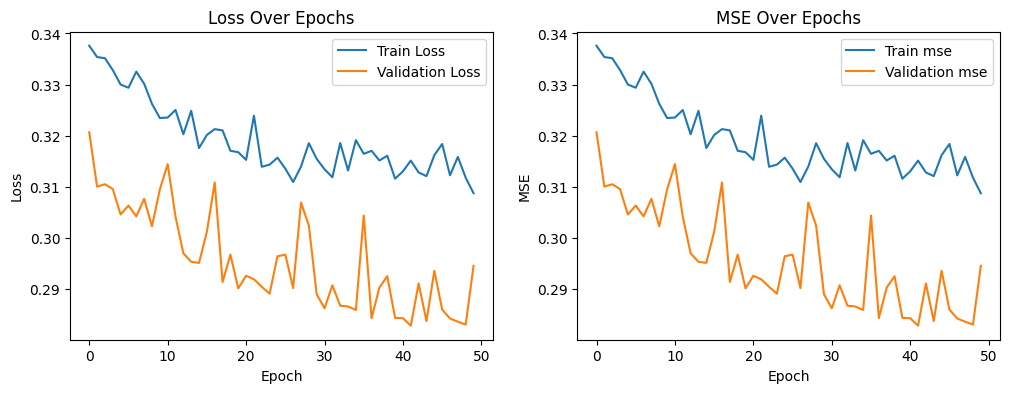

In [39]:
# Plot loss and accuracy
plt.figure(figsize=(12,4))

# Loss
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Accuracy
plt.subplot(1,2,2)
plt.plot(history.history['mse'], label='Train mse')
plt.plot(history.history['val_mse'], label='Validation mse')
plt.title('MSE Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()
plt.show()

Both the loss and mse charts show a reducing trend both for both the validation data and training data which is good. The training loss and mse are higher than in the validation data which is expected since it is the first time the model is seeing this data.

In [40]:
evaluation = model.evaluate(X_test, y_test, verbose=0)
print(evaluation)

[0.29455938935279846, 0.29455938935279846]


In [41]:
from sklearn.metrics import r2_score

# Make predictions on the test set using the deep learning model
y_test_pred_dl = model.predict(X_test_scaled)

# Calculate the R-squared score
r2_dl = r2_score(y_test, y_test_pred_dl)

print(f"R-squared for the Deep Learning model on the test set: {r2_dl:.4f}")

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
R-squared for the Deep Learning model on the test set: -6.2569


The deep learning model has a low mse but a very poor r-squared but the other models performed better meaning that maybe this wasn't the best model for this task. The model is the RandomForestRegressor for this task.